# 02 — Exploratory Data Analysis

The purpose of this notebook is to explore the dataset in more depth and identify patterns that may help explain customer churn.

In this notebook, we will:
- Examine the distribution of the target variable (`Exited`)
- Analyze the main numerical and categorical features
- Compare churn patterns across customer groups
- Investigate unusual values worth exploring further
- Summarize the main insights for the modeling stage

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid')
from IPython.display import display

In [ ]:
# Read the dataset and display the first few rows
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Quick copy for EDA

For most plots, ID-like columns are not useful, so we create a lighter copy for analysis.  
We keep the original `df` unchanged and work with `df_eda`.

In [3]:
# Drop unnecessary columns for EDA and create a copy of the DataFrame
df_eda = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()
print(df_eda.shape)
df_eda.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Target distribution

This is the same we saw in data_understanding Notebook, although here it's important to show. This us confirm whether the target is balanced or imbalanced.

In [4]:
exited_counts = df_eda['Exited'].value_counts().sort_index()
exited_pct = df_eda['Exited'].value_counts(normalize=True).sort_index().mul(100)

summary_target = pd.DataFrame({
    'count': exited_counts,
    'percentage': exited_pct.round(2)
})
summary_target.index = ['Stayed (0)', 'Exited (1)']
summary_target

,count,percentage
Stayed (0),7963,79.63
Exited (1),2037,20.37


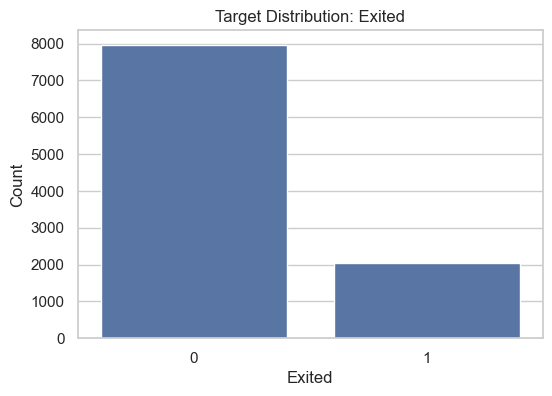

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x='Exited')
plt.title('Target Distribution: Exited')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

As we can see, the target variable is imbalanced because the number of customers who stayed is much higher than the number of customers who exited. This means that accuracy alone may be misleading, since a model could perform well on the majority class while failing to identify customers who churn.

## 3. Numerical feature distributions

We inspect the main numerical columns to understand their shape, spread, and possible unusual values.

In [ ]:
# Display summary statistics for numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df_eda[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.91,149388.25,199992.48


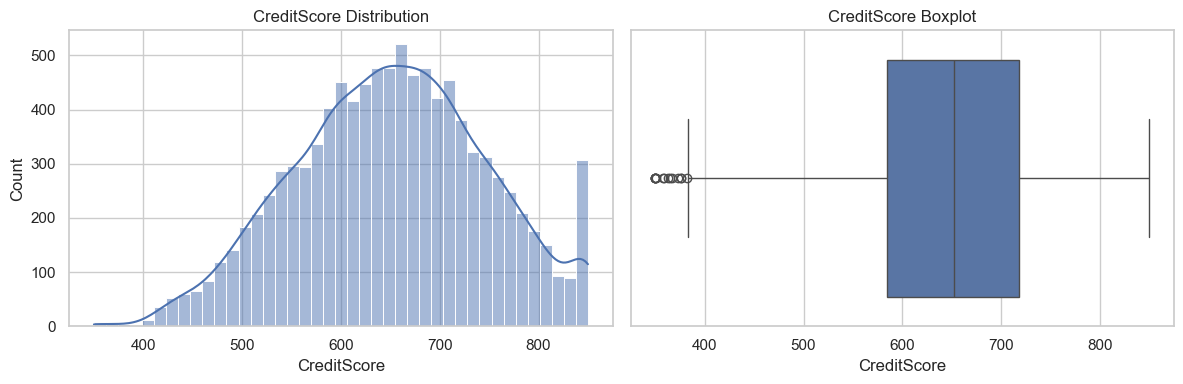

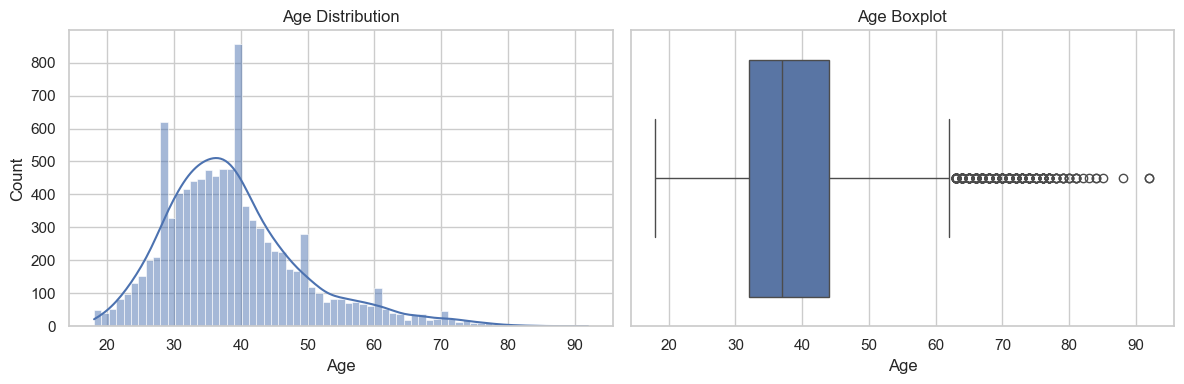

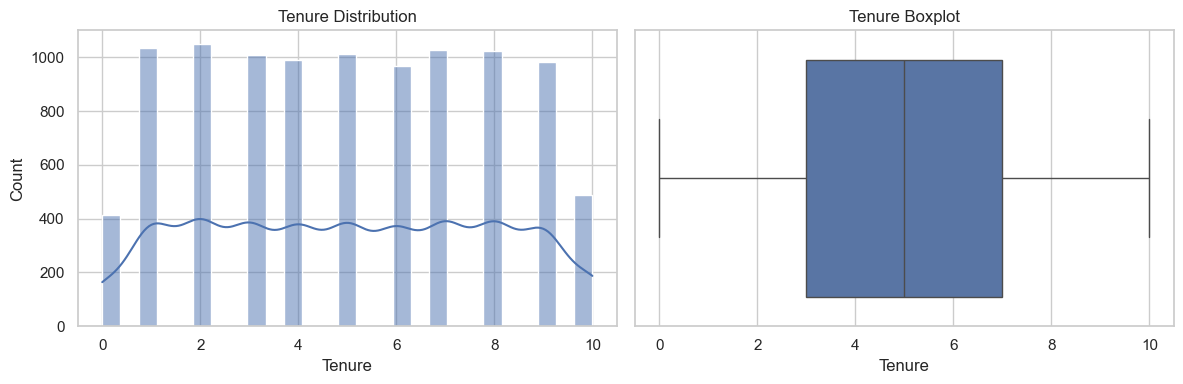

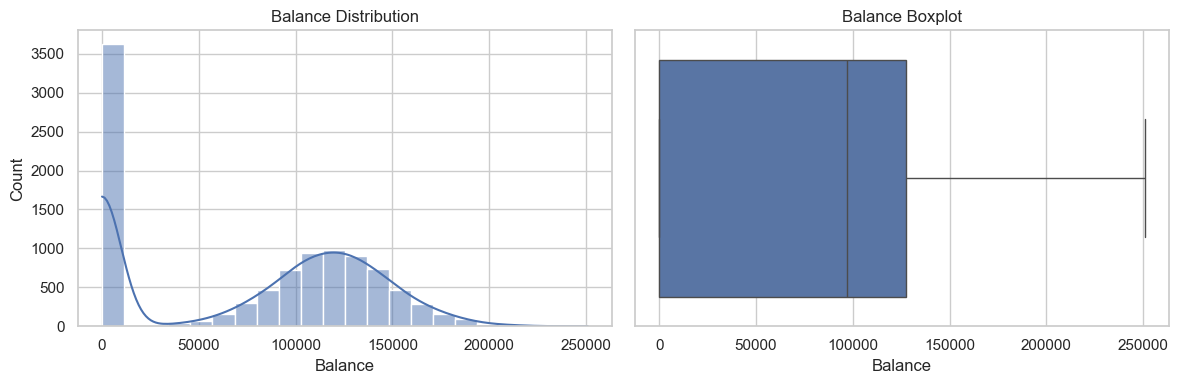

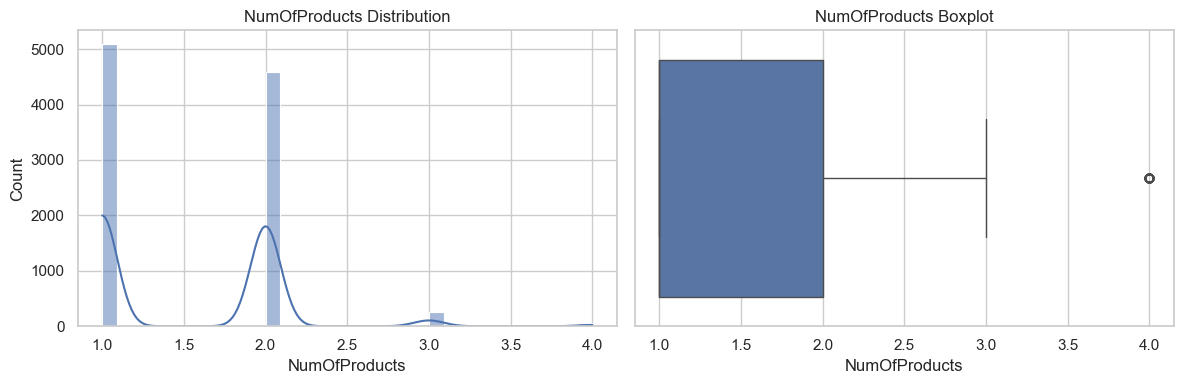

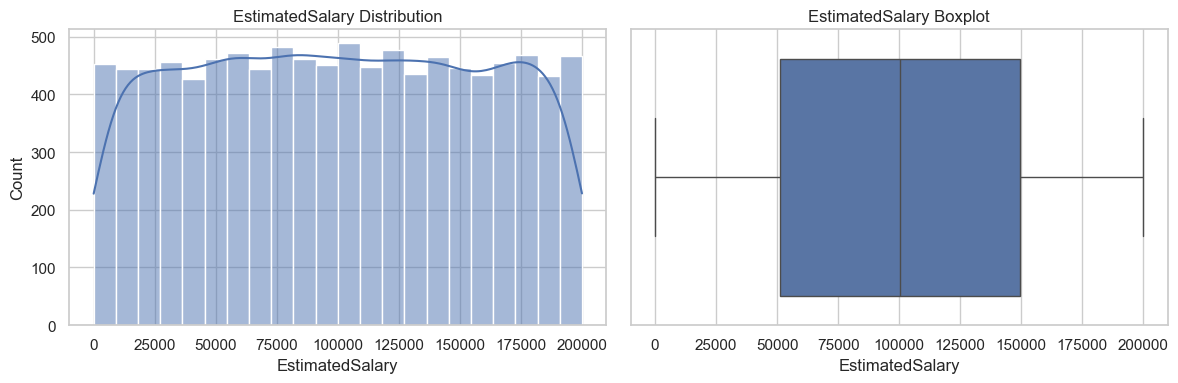

In [ ]:
# Visualize the distribution of numerical features
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_eda[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')
    sns.boxplot(x=df_eda[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')
    plt.tight_layout()
    plt.show()

The numerical summary does not reveal obvious data errors, and the variables appear generally suitable for analysis. However, some features such as `Age`, `CreditScore`, `Balance`, and `EstimatedSalary` contain extreme or unusual values that deserve further exploration in EDA. These values should not be removed automatically, since they may represent real customer behavior rather than noise. In particular, the large number of customers with zero balance suggests a meaningful segment rather than an outlier issue.

## 4. Categorical and binary feature distributions

Now we inspect the categorical and binary variables to understand how the dataset is composed.

,count,percentage
Geography,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77


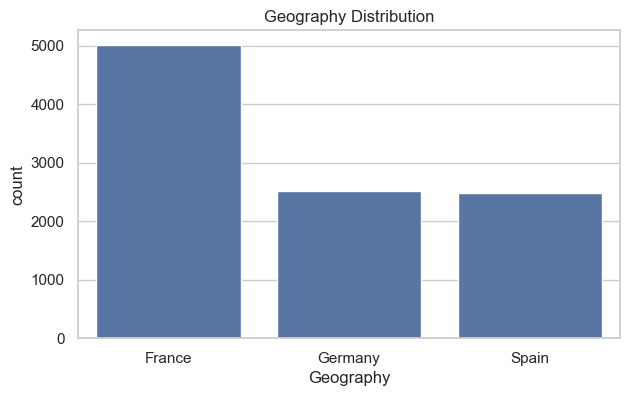

,count,percentage
Gender,,
Male,5457,54.57
Female,4543,45.43


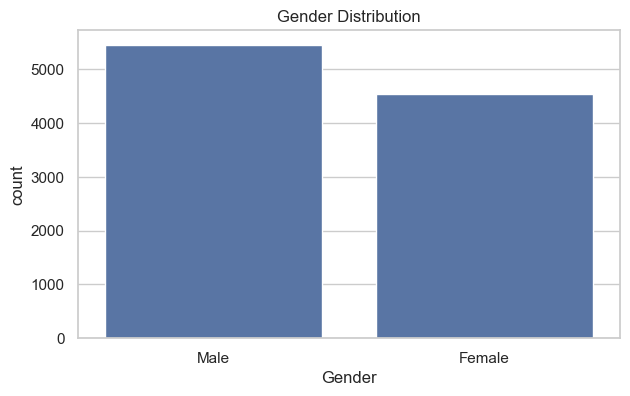

,count,percentage
HasCrCard,,
1,7055,70.55
0,2945,29.45


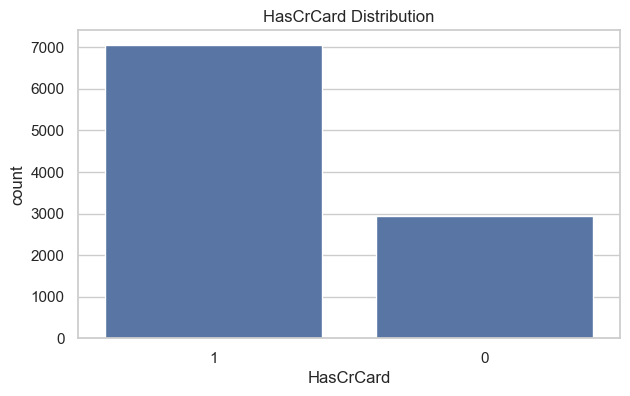

,count,percentage
IsActiveMember,,
1,5151,51.51
0,4849,48.49


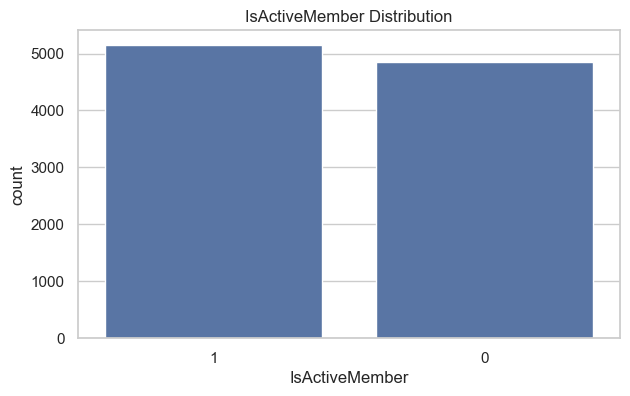

,count,percentage
NumOfProducts,,
1,5084,50.84
2,4590,45.90
3,266,2.66
4,60,0.60


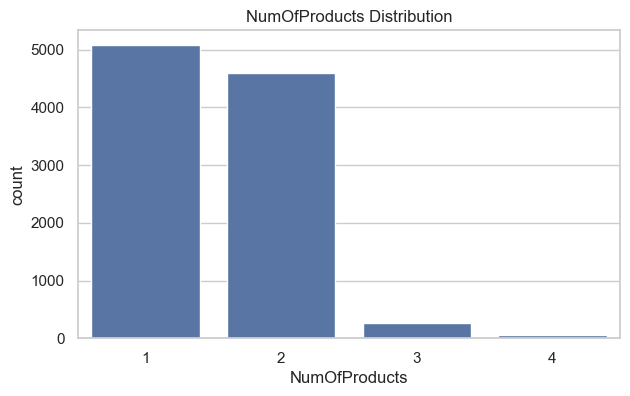

In [11]:
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

for col in categorical_cols:
    display(
        pd.DataFrame({
            'count': df_eda[col].value_counts(),
            'percentage': df_eda[col].value_counts(normalize=True).mul(100).round(2)
        })
    )
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_eda, x=col, order=df_eda[col].value_counts().index)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=0)
    plt.show()

The categorical features show different distribution patterns across the dataset. `Geography` is moderately unbalanced, with France representing about half of the customers, while Germany and Spain account for roughly one quarter each. `Gender` is relatively balanced, with a slightly higher proportion of male customers. `HasCrCard` is more unevenly distributed, since most customers own a credit card. Finally, `NumOfProducts` is strongly concentrated in the values 1 and 2, while customers with 3 or 4 products are rare. Overall, these features appear suitable for analysis, and some of them may provide useful information for explaining churn.

## 5. Numerical features vs churn

These plots help us compare the distribution of each numerical feature across the two target classes.

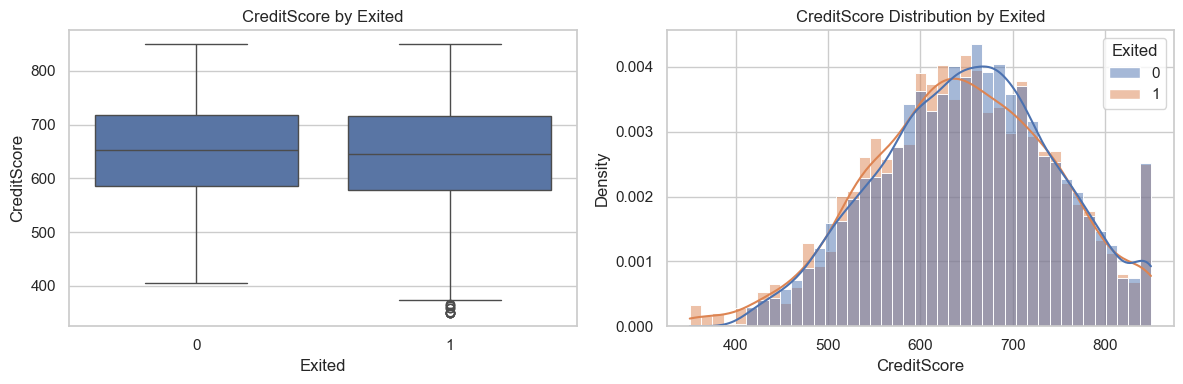

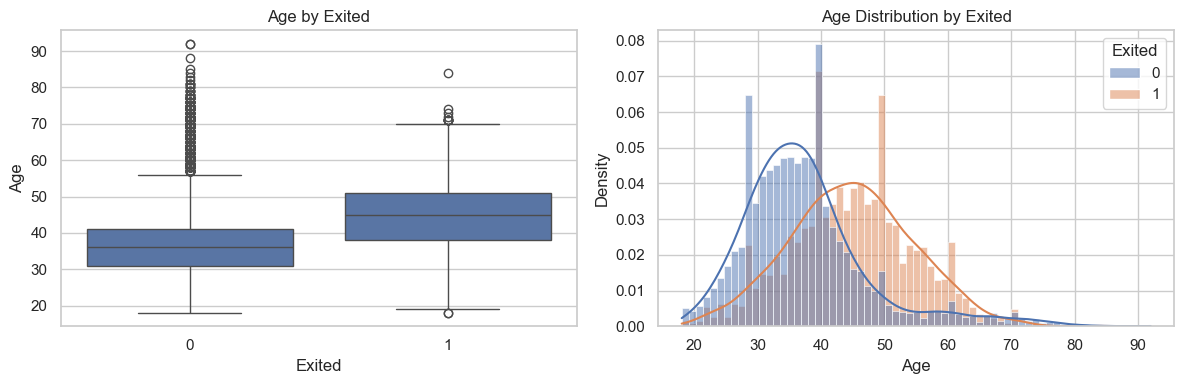

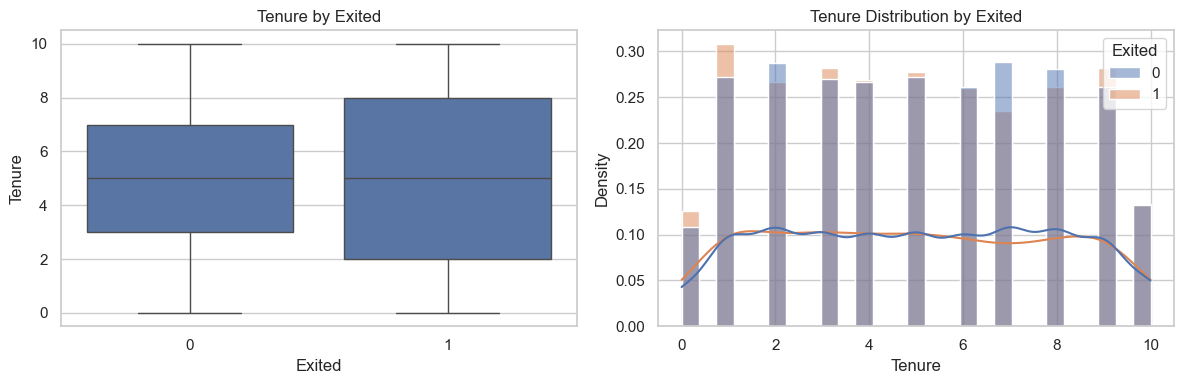

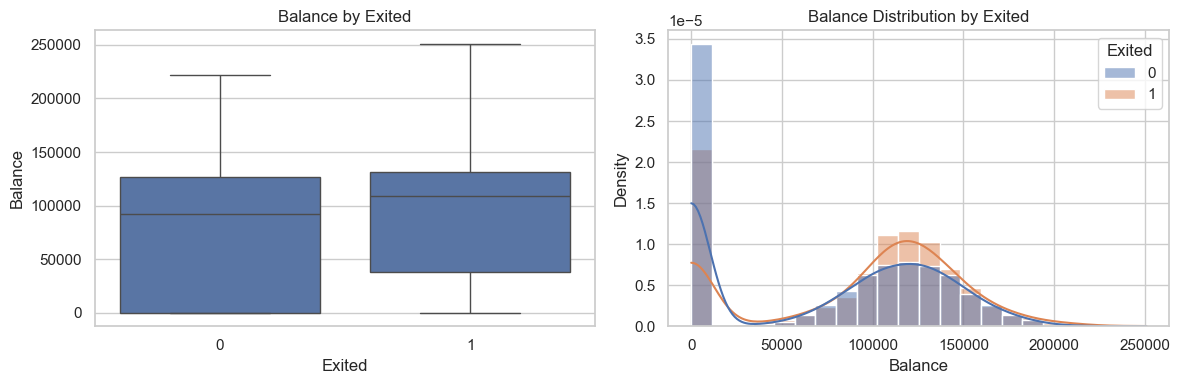

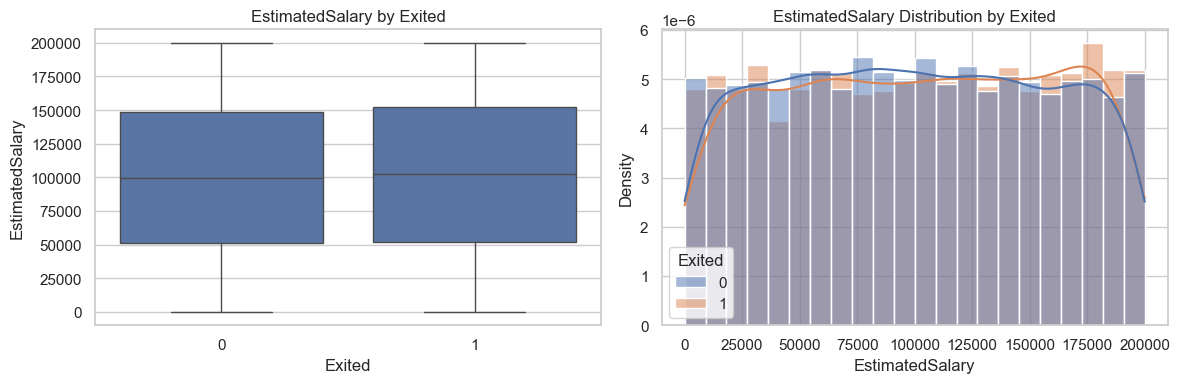

In [12]:
for col in ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=df_eda, x='Exited', y=col, ax=axes[0])
    axes[0].set_title(f'{col} by Exited')
    sns.histplot(data=df_eda, x=col, hue='Exited', kde=True, stat='density', common_norm=False, ax=axes[1])
    axes[1].set_title(f'{col} Distribution by Exited')
    plt.tight_layout()
    plt.show()

In [13]:
num_churn_summary = df_eda.groupby('Exited')[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']].mean().T
num_churn_summary.columns = ['Stayed (0)', 'Exited (1)']
num_churn_summary

,Stayed (0),Exited (1)
CreditScore,651.85,645.35
Age,37.41,44.84
Tenure,5.03,4.93
Balance,72745.30,91108.54
EstimatedSalary,99738.39,101465.68


By comparing the average numerical values between customers who stayed and customers who exited, we can identify which variables may be more relevant for explaining churn. Customers who exited are, on average, older and have higher account balances than those who stayed, suggesting that `Age` and `Balance` may be important features for the prediction task. `CreditScore` is slightly lower among churned customers, which may indicate a weaker relationship with churn. In contrast, `Tenure` and `EstimatedSalary` show very similar average values in both groups, so they may have less explanatory power at this stage of the analysis.